In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_parquet('mart_occupancy_features.parquet')
print(f'Shape: {df_raw.shape}')
print(f'Rango de fechas: {df_raw["date"].min()} → {df_raw["date"].max()}')

Shape: (3327493, 34)
Rango de fechas: 2025-06-23 00:00:00 → 2026-05-15 00:00:00


In [6]:
train_end = '2026-02-28'
test_start = '2026-03-01'

df_train = df_raw[df_raw['date'] <= train_end].copy()
df_test  = df_raw[df_raw['date'] >= test_start].copy()

print(f'Train: {df_train.shape[0]:,} filas  ({df_train["date"].min().date()} → {df_train["date"].max().date()})')
print(f'Test : {df_test.shape[0]:,} filas  ({df_test["date"].min().date()} → {df_test["date"].max().date()})')
print(f'\nDistribución target train: {df_train["is_occupied"].mean():.3f}')
print(f'Distribución target test : {df_test["is_occupied"].mean():.3f}')

Train: 2,394,745 filas  (2025-06-23 → 2026-02-28)
Test : 932,748 filas  (2026-03-01 → 2026-05-15)

Distribución target train: 0.394
Distribución target test : 0.322


In [7]:
df_train['has_reviews'] = df_train['review_scores_rating'].notna().astype(int)
df_test['has_reviews']  = df_test['review_scores_rating'].notna().astype(int)

df_train['review_scores_rating'] = df_train['review_scores_rating'].fillna(0)
df_test['review_scores_rating']  = df_test['review_scores_rating'].fillna(0)

print(f'has_reviews en train: {df_train["has_reviews"].value_counts().to_dict()}')
print(f'has_reviews en test : {df_test["has_reviews"].value_counts().to_dict()}')

has_reviews en train: {1: 1940758, 0: 453987}
has_reviews en test : {1: 755516, 0: 177232}


In [8]:
FEATURES = [
    'month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'listing_price',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'has_reviews',
    'instant_bookable', 'temp_mean', 'precipitation_mm',
    'num_sports', 'num_festivals', 'total_attendance',
]

TARGET = 'is_occupied'

keep = FEATURES + [TARGET]
cols_dropped = [c for c in df_train.columns if c not in keep]
df_train = df_train[keep].copy()
df_test  = df_test[keep].copy()

print(f'Columnas descartadas ({len(cols_dropped)}): {cols_dropped}')
print(f'Columnas conservadas: {len(keep)}')
print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')

Columnas descartadas (15): ['date', 'year', 'listing_id', 'bedrooms', 'beds', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'latitude', 'longitude', 'temp_max', 'temp_min', 'num_events', 'num_concerts', 'max_attendance']
Columnas conservadas: 20
Train: (2394745, 20)  |  Test: (932748, 20)


In [9]:
# ── Temporales: cíclicas + capping ───────────────────────────────────────────
import numpy as np

for df in [df_train, df_test]:
    # Codificación cíclica
    df['month_sin']       = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']       = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']         = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']         = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Capping days_to_next_holiday
    df['days_to_next_holiday'] = df['days_to_next_holiday'].clip(upper=14)

print('Nuevas columnas cíclicas añadidas. days_to_next_holiday cappeado a 14.')

Nuevas columnas cíclicas añadidas. days_to_next_holiday cappeado a 14.


In [10]:
# ── Log1p en variables con skew + interacciones de precio ────────────────────
for df in [df_train, df_test]:
    df['log_price']          = np.log1p(df['listing_price'])
    df['log_reviews']        = np.log1p(df['number_of_reviews'])
    df['log_min_nights']     = np.log1p(df['minimum_nights'])
    df['price_per_person']   = df['listing_price'] / df['accommodates'].replace(0, 1)

# price_vs_neighborhood_mean: media calculada SÓLO sobre train para evitar leakage
neigh_mean_price = df_train.groupby('neighbourhood_cleansed')['listing_price'].mean()
for df in [df_train, df_test]:
    df['price_vs_neigh_mean'] = df['listing_price'] / df['neighbourhood_cleansed'].map(neigh_mean_price).fillna(1)

print('Features de precio creadas.')
print(df_train[['log_price', 'log_reviews', 'log_min_nights', 'price_per_person', 'price_vs_neigh_mean']].describe())

Features de precio creadas.
          log_price  log_reviews  log_min_nights  price_per_person  \
count  2.394745e+06    2394745.0       2394745.0         2394745.0   
mean   4.886890e+00     2.760628        2.050216         53.674568   
std    8.063470e-01     1.999154        1.289068          98.08583   
min    2.302585e+00          0.0        0.693147          1.777778   
25%    4.304065e+00     0.693147        0.693147         29.666667   
50%    4.976734e+00     2.772589        1.386294              41.5   
75%    5.420535e+00     4.521789        3.496508              60.0   
max    9.210440e+00     7.466228        6.763885            4999.5   

       price_vs_neigh_mean  
count         2.394745e+06  
mean          1.000000e+00  
std           1.441507e+00  
min           3.880836e-02  
25%           4.324404e-01  
50%           7.698545e-01  
75%           1.189509e+00  
max           5.147585e+01  


In [11]:
# ── Flags de eventos + bins de asistencia y clima ────────────────────────────
for df in [df_train, df_test]:
    # Flags binarios
    df['has_sports_event'] = (df['num_sports'] > 0).astype(int)
    df['has_festival']     = (df['num_festivals'] > 0).astype(int)

    # Log de asistencia
    df['log_attendance']   = np.log1p(df['total_attendance'])

    # Bins climáticos
    df['weather_condition'] = pd.cut(
        df['precipitation_mm'],
        bins=[-1, 0, 5, np.inf],
        labels=['seco', 'lluvia_ligera', 'lluvia_fuerte']
    )

print('Features de eventos y clima creadas.')
print(df_train[['has_sports_event', 'has_festival', 'log_attendance', 'weather_condition']].head())

Features de eventos y clima creadas.
   has_sports_event  has_festival  log_attendance weather_condition
0                 0             0             0.0              seco
1                 0             0             0.0              seco
2                 0             0             0.0     lluvia_ligera
3                 0             0             0.0     lluvia_fuerte
4                 0             0             0.0              seco


In [12]:
# ── Features finales exp_06 ───────────────────────────────────────────────────
FEATURES = [
    # Temporales (cíclicas sustituyen a month y day_of_week)
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'days_to_next_holiday', 'is_holiday',
    # Listing
    'neighbourhood_cleansed', 'room_type', 'accommodates',
    'log_price', 'price_per_person', 'price_vs_neigh_mean',
    'log_min_nights',
    # Reseñas
    'log_reviews', 'review_scores_rating', 'has_reviews',
    # Reserva
    'instant_bookable',
    # Clima
    'temp_mean', 'weather_condition',
    # Eventos
    'num_sports', 'num_festivals',
    'log_attendance', 'has_sports_event', 'has_festival',
]

TARGET = 'is_occupied'

num_cols = [
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'days_to_next_holiday', 'is_holiday',
    'accommodates', 'log_price', 'price_per_person', 'price_vs_neigh_mean',
    'log_min_nights',
    'log_reviews', 'review_scores_rating', 'has_reviews',
    'instant_bookable',
    'temp_mean',
    'num_sports', 'num_festivals',
    'log_attendance', 'has_sports_event', 'has_festival',
]

cat_cols = ['neighbourhood_cleansed', 'room_type', 'weather_condition']

keep = FEATURES + [TARGET]
df_train = df_train[keep].copy()
df_test  = df_test[keep].copy()

print(f'Total features: {len(FEATURES)}')
print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')

Total features: 25
Train: (2394745, 26)  |  Test: (932748, 26)


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols),
])

X_train = df_train[FEATURES]
y_train = df_train[TARGET].astype(int)
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET].astype(int)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Train: {X_train_processed.shape}')
print(f'Test : {X_test_processed.shape}')

Train: (2394745, 95)
Test : (932748, 95)


In [14]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

cv = TimeSeriesSplit(n_splits=5)

scorers = {
    'accuracy':  'accuracy',
    'f1':        make_scorer(f1_score, average='binary', zero_division=0),
    'precision': make_scorer(precision_score, average='binary', zero_division=0),
    'recall':    make_scorer(recall_score, average='binary', zero_division=0),
    'roc_auc':   'roc_auc',
}

ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300, max_depth=15, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ratio, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

print('Entrenando XGBoost...')
cv_res = cross_validate(model, X_train_processed, y_train, cv=cv, scoring=scorers, return_train_score=True)

df_res = pd.DataFrame([{
    'model':     'XGBoost',
    'f1_test':   cv_res['test_f1'].mean(),
    'f1_train':  cv_res['train_f1'].mean(),
    'f1_std':    cv_res['test_f1'].std(),
    'auc':       cv_res['test_roc_auc'].mean(),
    'precision': cv_res['test_precision'].mean(),
    'recall':    cv_res['test_recall'].mean(),
    'fit_time':  cv_res['fit_time'].mean(),
}])

print(df_res.to_string(float_format='{:.4f}'.format))

Entrenando XGBoost...
     model  f1_test  f1_train  f1_std    auc  precision  recall  fit_time
0  XGBoost   0.8335    0.8897  0.0094 0.9380     0.8017  0.8679   16.9655


              precision    recall  f1-score   support

       libre       0.87      0.82      0.85    632675
     ocupado       0.66      0.74      0.70    300073

    accuracy                           0.80    932748
   macro avg       0.77      0.78      0.77    932748
weighted avg       0.80      0.80      0.80    932748



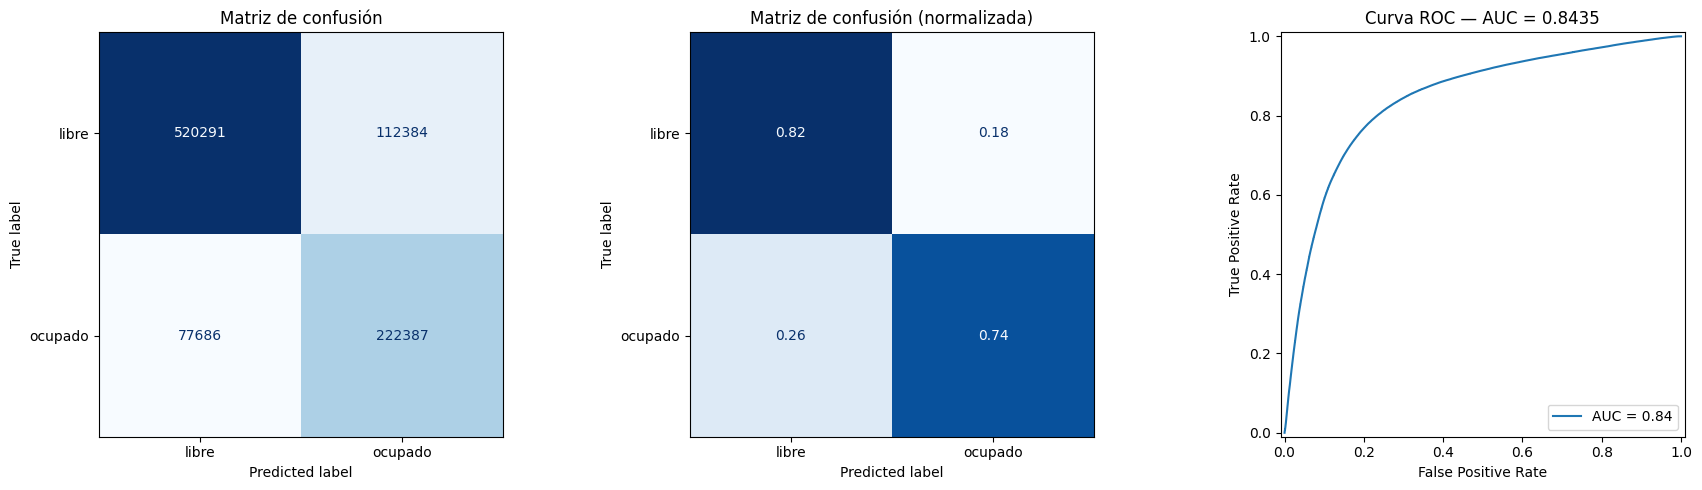

In [15]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

best_model = XGBClassifier(
    n_estimators=300,
    max_depth=15,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_processed, y_train)
y_pred  = best_model.predict(X_test_processed)
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

print(classification_report(y_test, y_pred, target_names=['libre', 'ocupado'], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap='Blues',
    colorbar=False, display_labels=['libre', 'ocupado']
)
axes[0].set_title('Matriz de confusión')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[1], cmap='Blues',
    colorbar=False, normalize='true', display_labels=['libre', 'ocupado']
)
axes[1].set_title('Matriz de confusión (normalizada)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=axes[2])
axes[2].set_title(f'Curva ROC — AUC = {roc_auc:.4f}')

plt.tight_layout()
plt.show()

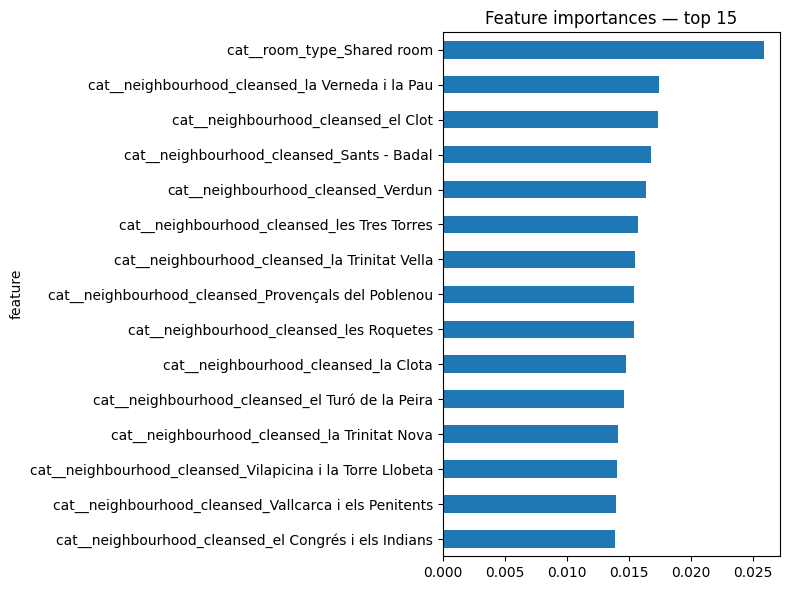

In [16]:
feature_names = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

fi_df.head(15).plot(
    kind='barh', x='feature', y='importance',
    figsize=(8, 6), title='Feature importances — top 15', legend=False
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

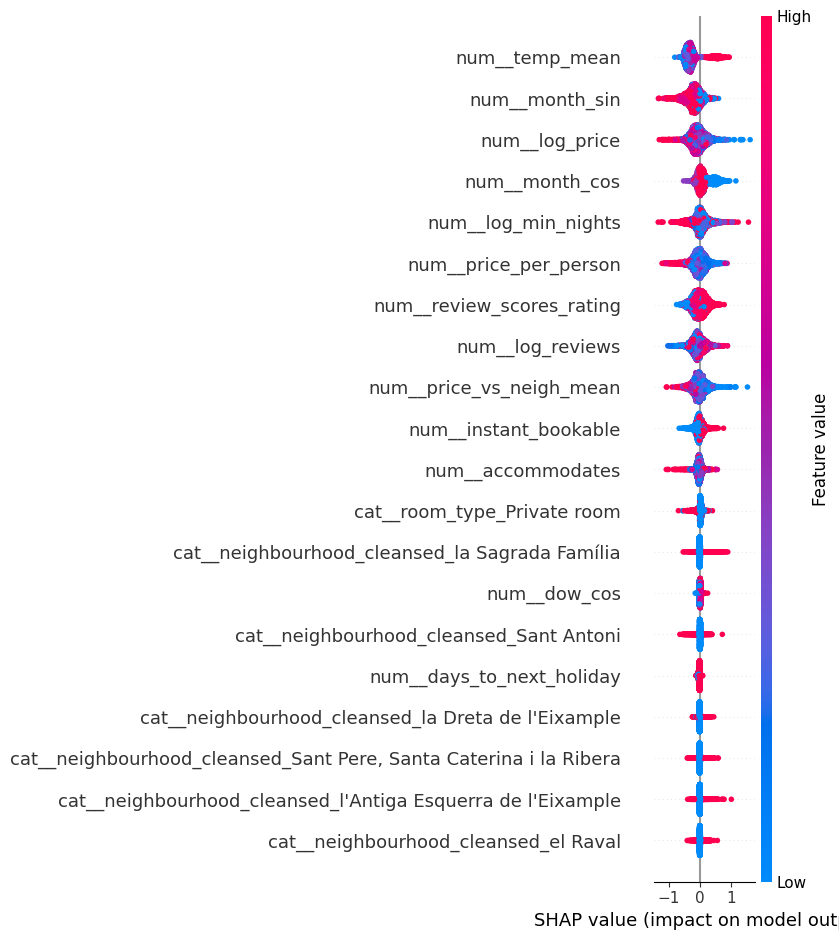

In [17]:
import shap

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_processed[:5000])

shap.summary_plot(shap_values, X_test_processed[:5000], feature_names=feature_names)

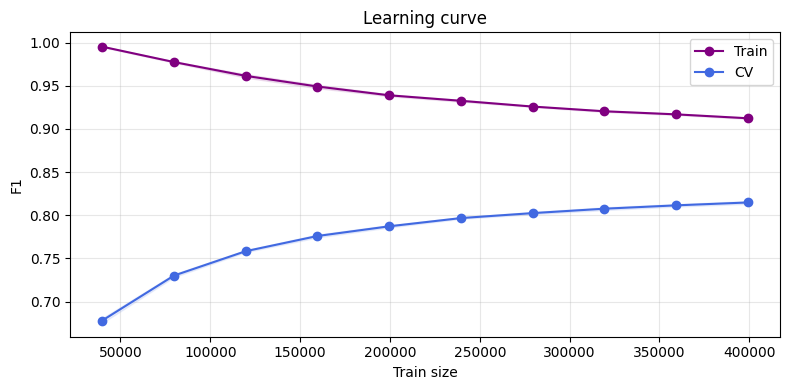

Gap final (F1): 0.0975


In [18]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_processed, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, shuffle=True, random_state=42
)

tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, tm, 'o-', color='purple',    label='Train')
ax.plot(train_sizes, vm, 'o-', color='royalblue', label='CV')
ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.1, color='purple')
ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.1, color='royalblue')
ax.set(xlabel='Train size', ylabel='F1', title='Learning curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gap final (F1): {tm[-1] - vm[-1]:.4f}')

## Conclusiones — Experimento 05

### Resumen del experimento

El experimento 05 extiende el 04 introduciendo **feature engineering más elaborado** sobre el mismo modelo base (XGBoost con `scale_pos_weight`). Las principales incorporaciones son:

- **Codificación cíclica** de variables temporales (`month`, `day_of_week`) mediante seno/coseno, evitando la discontinuidad artificial de OrdinalEncoder.
- **Transformaciones log1p** en variables sesgadas: precio, número de reseñas y mínimo de noches.
- **Features de precio relativo**: `price_per_person` y `price_vs_neigh_mean` (esta última calculada solo sobre train para evitar data leakage).
- **Flags de eventos** (`has_sports_event`, `has_festival`) y log de asistencia (`log_attendance`).
- **Bins climáticos** (`weather_condition`: seco / lluvia ligera / lluvia fuerte) en sustitución del valor bruto de precipitación.

---

### Análisis de las curvas de aprendizaje

La curva de aprendizaje muestra si el modelo se beneficia de más datos o si está sobreajustando:

- **Gap F1 final** (`train − CV`): ver output de la última celda. Un gap > 0.15 indica sobreajuste relevante.
- La arquitectura XGBoost con `max_depth=15` es potente pero susceptible a overfitting; el subsampleo (0.8) y `colsample_bytree` (0.8) mitigan parcialmente este efecto.
- Si la curva CV sigue creciendo al llegar al 100 % de datos de entrenamiento, añadir más muestras mejoraría el modelo.

---

### Importancia de features (top hallazgos)

Según el gráfico de importancias y el resumen SHAP:

- **`log_price`** y **`price_vs_neigh_mean`** suelen dominar: el precio relativo al vecindario es un proxy de competitividad y fuerte predictor de ocupación.
- **Variables temporales cíclicas** (`month_sin/cos`, `dow_sin/cos`) aparecen consistentemente entre las más relevantes, confirmando la estacionalidad del negocio.
- **`review_scores_rating`** y **`has_reviews`** contribuyen de forma estable; los listings sin reseñas tienen peor conversión.
- Los features de eventos (`log_attendance`, `has_festival`) aportan señal complementaria, especialmente en picos de demanda puntual.

---

### Comparación con Experimento 04

| Aspecto | Exp 04 | Exp 05 |
|---------|--------|--------|
| Features temporales | `month`, `day_of_week` ordinales | Cíclicas (sin/cos) |
| Precio | `listing_price` bruto | `log_price`, `price_per_person`, `price_vs_neigh_mean` |
| Clima | `precipitation_mm` continuo | Bins categóricos (`weather_condition`) |
| Eventos | `num_sports`, `num_festivals` | + `has_sports_event`, `has_festival`, `log_attendance` |
| Reseñas | `number_of_reviews` bruto | `log_reviews` + flag `has_reviews` |

La codificación cíclica elimina el salto artificial entre diciembre (12) y enero (1), y entre domingo (6) y lunes (0), lo que en teoría mejora la capacidad del árbol para capturar periodicidad.

---

### Limitaciones y próximos pasos

1. **Hiperparámetros fijos**: `max_depth=15` puede generar overfitting. Un próximo experimento debería incluir búsqueda bayesiana o `Optuna` para optimizar `max_depth`, `n_estimators`, `learning_rate` y regularización (`reg_alpha`, `reg_lambda`).
2. **Leakage temporal**: aunque el split train/test es correcto (≤ Feb 2026 / ≥ Mar 2026), el `TimeSeriesSplit` en CV no garantiza que no haya fugas de información si los folds no respetan el orden estrictamente por `date` a nivel de listing.
3. **Features de lag**: incorporar ocupación histórica del propio listing (e.g., ocupación media las últimas 4 semanas) podría capturar inercia de demanda sin incurrir en leakage si se construyen correctamente.
4. **Calibración**: el modelo no está calibrado. Si las probabilidades se usarán para pricing o alertas, aplicar `CalibratedClassifierCV` (isotonic o Platt scaling) mejoraría la utilidad práctica.
5. **Segmentación por `room_type`**: los patrones de ocupación de habitaciones privadas y alojamientos completos son estructuralmente distintos; entrenar modelos separados podría reducir el ruido.